In [108]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
df1 = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df1.head()
#Reading and printing the first 5 rows for training 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [110]:
df2 = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
df2.head()
#Reading first 5 of test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [111]:
df1.isna().sum()
#Checking total null values in the training dataset

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [112]:
df2.isna().sum()
#checking total null values in the test dataset

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

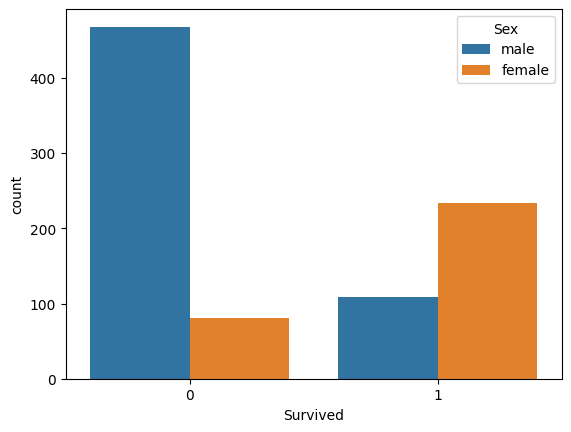

In [113]:
sns.countplot(data=df1, x='Survived', hue='Sex')
plt.show()
#0 tells us not survived and we can see that most of the people who died were men and 1 tells us about those who survived and the ones who survived are women

In [114]:
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())
df2['Age'] = df2['Age'].fillna(df2['Age'].mean())
df2['Fare'] = df2['Fare'].fillna(df2['Fare'].mean())
#Here, I am replacing all the missing values with the mean of that particular column

In [115]:
df1['Sex'] = df1['Sex'].map({'male': 0, 'female': 1})
df2['Sex'] = df2['Sex'].map({'male': 0, 'female': 1})
# Here im replacing male with 0 and female with 1

In [124]:
print(df1.isna().sum())
print(df2.isna().sum())
# Just checking if there was a typo with the terms "male" or "female" which map might have ncountered

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [116]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df1[features]
y = df1['Survived']#Using only some of the features

In [117]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#Feature Scaling

In [118]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
#Training model

In [119]:
model = LogisticRegression()
model.fit(X_train, y_train)
#Training model

LogisticRegression()

In [120]:
val_pred = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_pred) * 100:.2f}%")
#Checking accuracy

Validation Accuracy: 79.89%


In [121]:
X_test = df2[features]
X_test_scaled = scaler.transform(X_test)
final_predictions = model.predict(X_test_scaled)
#Prediciting the values on df2(Test Data)

In [122]:
submission = pd.DataFrame({
    'PassengerId': df2['PassengerId'],
    'Survived': final_predictions
})
submission.to_csv('answer.csv', index=False)
# Final file